In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

hearth_disease_recognition_path = kagglehub.competition_download('super-ai-engineer-ss-6-heart-disease-prediction')

print(hearth_disease_recognition_path)

/root/.cache/kagglehub/competitions/super-ai-engineer-ss-6-heart-disease-prediction


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# **Prepare Data**

In [ ]:
!pip install autogluon.tabular

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from autogluon.tabular import TabularPredictor
from autogluon.core.metrics import make_scorer
from sklearn.metrics import fbeta_score
import zipfile
warnings.filterwarnings("ignore")

In [ ]:
train_df = pd.read_csv("/root/.cache/kagglehub/competitions/super-ai-engineer-ss-6-heart-disease-prediction/train.csv")
test_df = pd.read_csv("/root/.cache/kagglehub/competitions/super-ai-engineer-ss-6-heart-disease-prediction/test.csv")

# **Exploratory Data Analysis**

## Data

In [ ]:
train_df.isna()

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223079,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
223080,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
223081,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
223082,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
train_df.head()

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
4,train_000005,NaN,Yes,Yes,Yes,34.56,Yes,No,No,Yes,No,Yes,Yes,Very Poor,Yes,Male,Some high school,"$15,000 to less than $20,000",98,Yes


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74361 entries, 0 to 74360
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   ID                                      74361 non-null  object 
 1   High Blood Pressure                     74361 non-null  object 
 2   Told High Cholesterol                   74361 non-null  object 
 3   Cholesterol Checked                     74361 non-null  object 
 4   Body Mass Index                         74361 non-null  float64
 5   Smoked 100+ Cigarettes                  74361 non-null  object 
 6   Diagnosed Stroke                        74361 non-null  object 
 7   Diagnosed Diabetes                      74361 non-null  object 
 8   Leisure Physical Activity               74361 non-null  object 
 9   Heavy Alcohol Consumption               74361 non-null  object 
 10  Health Care Coverage                    74361 non-null  ob

## Statistic

In [ ]:
train_df.describe()

,Body Mass Index,Age
count,211302.000000,223084.000000
mean,28.189817,54.739717
std,6.688447,17.795140
min,11.210000,18.000000
25%,23.880000,42.000000
50%,27.070000,56.000000
75%,31.100000,67.000000
max,98.630000,100.000000


In [ ]:
test_df.describe()

,Body Mass Index,Age
count,74361.000000,74361.000000
mean,28.402408,57.722112
std,6.598611,16.449871
min,11.490000,18.000000
25%,24.110000,47.000000
50%,27.300000,59.000000
75%,31.350000,69.000000
max,96.950000,100.000000


## Balance

<Axes: xlabel='History of HeartDisease or Attack', ylabel='count'>

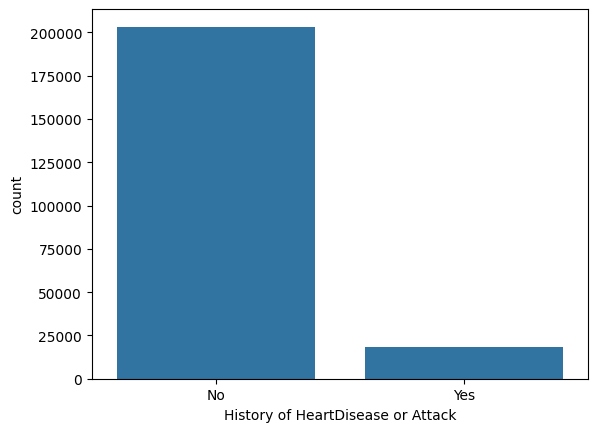

In [ ]:
sns.countplot(data=train_df, x='History of HeartDisease or Attack')

## Duplicate

In [ ]:
features = train_df.columns.values[2:21]
features

array(['High Blood Pressure', 'Told High Cholesterol',
       'Cholesterol Checked', 'Body Mass Index', 'Smoked 100+ Cigarettes',
       'Diagnosed Stroke', 'Diagnosed Diabetes',
       'Leisure Physical Activity', 'Heavy Alcohol Consumption',
       'Health Care Coverage', 'Doctor Visit Cost Barrier',
       'General Health', 'Difficulty Walking', 'Sex', 'Education Level',
       'Income Level', 'Age', 'Vegetable or Fruit Intake (1+ per Day)'],
      dtype=object)

In [ ]:
train_dp = []
test_dp = []
for i in features:
    f = train_df[i].value_counts()
    train_dp.append([i,f.max(),f.idxmax()])
    f = test_df[i].value_counts()
    test_dp.append([i,f.max(),f.idxmax()])
train_dp = pd.DataFrame(train_dp,columns=["Feature","Dup","Value"])
test_dp = pd.DataFrame(test_dp,columns=["Feature","Dup","Value"])

In [ ]:
train_dp

,Feature,Dup,Value
0,High Blood Pressure,136346,No
1,Told High Cholesterol,110468,No
2,Cholesterol Checked,183784,Yes
3,Body Mass Index,208,24.92
4,Smoked 100+ Cigarettes,125888,No
5,Diagnosed Stroke,214928,No
6,Diagnosed Diabetes,193459,No
7,Leisure Physical Activity,166976,Yes
8,Heavy Alcohol Consumption,210132,No
9,Health Care Coverage,206732,Yes


In [ ]:
test_dp

,Feature,Dup,Value
0,High Blood Pressure,42357,No
1,Told High Cholesterol,42685,No
2,Cholesterol Checked,71605,Yes
3,Body Mass Index,81,24.25
4,Smoked 100+ Cigarettes,41453,No
5,Diagnosed Stroke,71348,No
6,Diagnosed Diabetes,63521,No
7,Leisure Physical Activity,56192,Yes
8,Heavy Alcohol Consumption,70193,No
9,Health Care Coverage,70767,Yes


# **Analysis Data**

## Preprocess

In [ ]:
df_yes = train_df[train_df['History of HeartDisease or Attack'] == "Yes"].sample(n=16000, random_state=42)
df_no = train_df[train_df['History of HeartDisease or Attack'] == "No"].sample(n=16000, random_state=42)
train_df = pd.concat([df_yes,df_no],ignore_index = True)

<Axes: xlabel='History of HeartDisease or Attack', ylabel='count'>

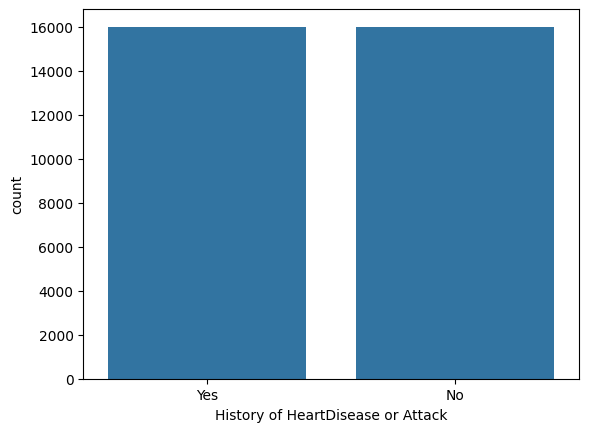

In [ ]:
sns.countplot(data=train_df, x='History of HeartDisease or Attack')

In [ ]:
train_df_tmp = train_df.copy()
test_df_tmp = test_df.copy()

In [ ]:
general_health = {'Excellent':2,'Good':1,'Fair':0,'Poor':-1,'Very Poor':-2}
income_level = {'$75,000 or more':8,'$50,000 to less than $75,000':7,'$35,000 to less than $50,000':6,'$25,000 to less than $35,000':5,'$20,000 to less than $25,000':4,'$15,000 to less than $20,000':3,'($10,000 to less than $15,000':2,'Less than $10,000':1}
yes_no = {'Yes':1,'No':0}
sex = {'Male':1,'Female':0}
yes_no_col_train = ['History of HeartDisease or Attack','High Blood Pressure','Told High Cholesterol','Cholesterol Checked','Smoked 100+ Cigarettes','Diagnosed Stroke','Diagnosed Diabetes',
             'Leisure Physical Activity','Heavy Alcohol Consumption','Doctor Visit Cost Barrier','Difficulty Walking','Vegetable or Fruit Intake (1+ per Day)','Health Care Coverage']
yes_no_col_test = ['High Blood Pressure','Told High Cholesterol','Cholesterol Checked','Smoked 100+ Cigarettes','Diagnosed Stroke','Diagnosed Diabetes',
             'Leisure Physical Activity','Heavy Alcohol Consumption','Doctor Visit Cost Barrier','Difficulty Walking','Vegetable or Fruit Intake (1+ per Day)','Health Care Coverage']
train_df_tmp[yes_no_col_train] = train_df_tmp[yes_no_col_train].replace(yes_no)
train_df_tmp['General Health'] = train_df_tmp['General Health'].replace(general_health)
train_df_tmp['Income Level'] = train_df_tmp['Income Level'].replace(income_level)
train_df_tmp['Sex'] = train_df_tmp['Sex'].replace(sex)
train_df_tmp.drop(['Education Level'], axis = 1,inplace = True)
train_df_tmp = train_df_tmp.dropna()
test_df_tmp[yes_no_col_test] = test_df_tmp[yes_no_col_test].replace(yes_no)
test_df_tmp['General Health'] = test_df_tmp['General Health'].replace(general_health)
test_df_tmp['Income Level'] = test_df_tmp['Income Level'].replace(income_level)
test_df_tmp['Sex'] = test_df_tmp['Sex'].replace(sex)
test_df_tmp.drop(['Education Level'], axis = 1,inplace = True)
test_df_tmp = test_df_tmp.dropna()

In [ ]:
train_df_tmp.drop(['Sex'], axis = 1,inplace = True)
train_df_tmp.drop(['Body Mass Index'], axis = 1,inplace = True)
train_df_tmp.drop(['Leisure Physical Activity'], axis = 1,inplace = True)
train_df_tmp.drop(['Smoked 100+ Cigarettes'], axis = 1,inplace = True)
train_df_tmp.drop(['Health Care Coverage'], axis = 1,inplace = True)
train_df_tmp.drop(['Cholesterol Checked'], axis = 1,inplace = True)
train_df_tmp.drop(['Vegetable or Fruit Intake (1+ per Day)'], axis = 1,inplace = True)
train_df_tmp.drop(['Doctor Visit Cost Barrier'], axis = 1,inplace = True)
train_df_tmp.drop(['ID'], axis = 1,inplace = True)
test_df_tmp.drop(['Sex'], axis = 1,inplace = True)
test_df_tmp.drop(['Body Mass Index'], axis = 1,inplace = True)
test_df_tmp.drop(['Leisure Physical Activity'], axis = 1,inplace = True)
test_df_tmp.drop(['Smoked 100+ Cigarettes'], axis = 1,inplace = True)
test_df_tmp.drop(['Health Care Coverage'], axis = 1,inplace = True)
test_df_tmp.drop(['Cholesterol Checked'], axis = 1,inplace = True)
test_df_tmp.drop(['Vegetable or Fruit Intake (1+ per Day)'], axis = 1,inplace = True)
test_df_tmp.drop(['Doctor Visit Cost Barrier'], axis = 1,inplace = True)
test_df_tmp.drop(['ID'], axis = 1,inplace = True)

In [ ]:
train_df_tmp

,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Diagnosed Stroke,Diagnosed Diabetes,Heavy Alcohol Consumption,General Health,Difficulty Walking,Income Level,Age
0,1,1,1.0,1,0.0,0,-2,1,8,47
1,1,1,1.0,1,1.0,0,-1,0,2,59
2,1,0,1.0,0,0.0,0,-1,1,8,58
3,1,1,1.0,1,1.0,0,1,1,4,64
4,1,1,1.0,0,0.0,0,-1,1,7,56
...,...,...,...,...,...,...,...,...,...,...
31993,0,1,1.0,0,0.0,0,0,0,8,36
31994,0,0,1.0,0,0.0,0,1,0,8,52
31995,0,0,0.0,0,0.0,0,2,0,8,65
31997,0,0,0.0,0,0.0,1,-1,0,8,56


## Raw Data

array([[<Axes: title={'center': 'History of HeartDisease or Attack'}>,
        <Axes: title={'center': 'High Blood Pressure'}>,
        <Axes: title={'center': 'Told High Cholesterol'}>],
       [<Axes: title={'center': 'Diagnosed Stroke'}>,
        <Axes: title={'center': 'Diagnosed Diabetes'}>,
        <Axes: title={'center': 'Heavy Alcohol Consumption'}>],
       [<Axes: title={'center': 'General Health'}>,
        <Axes: title={'center': 'Difficulty Walking'}>,
        <Axes: title={'center': 'Income Level'}>],
       [<Axes: title={'center': 'Age'}>, <Axes: >, <Axes: >]],
      dtype=object)

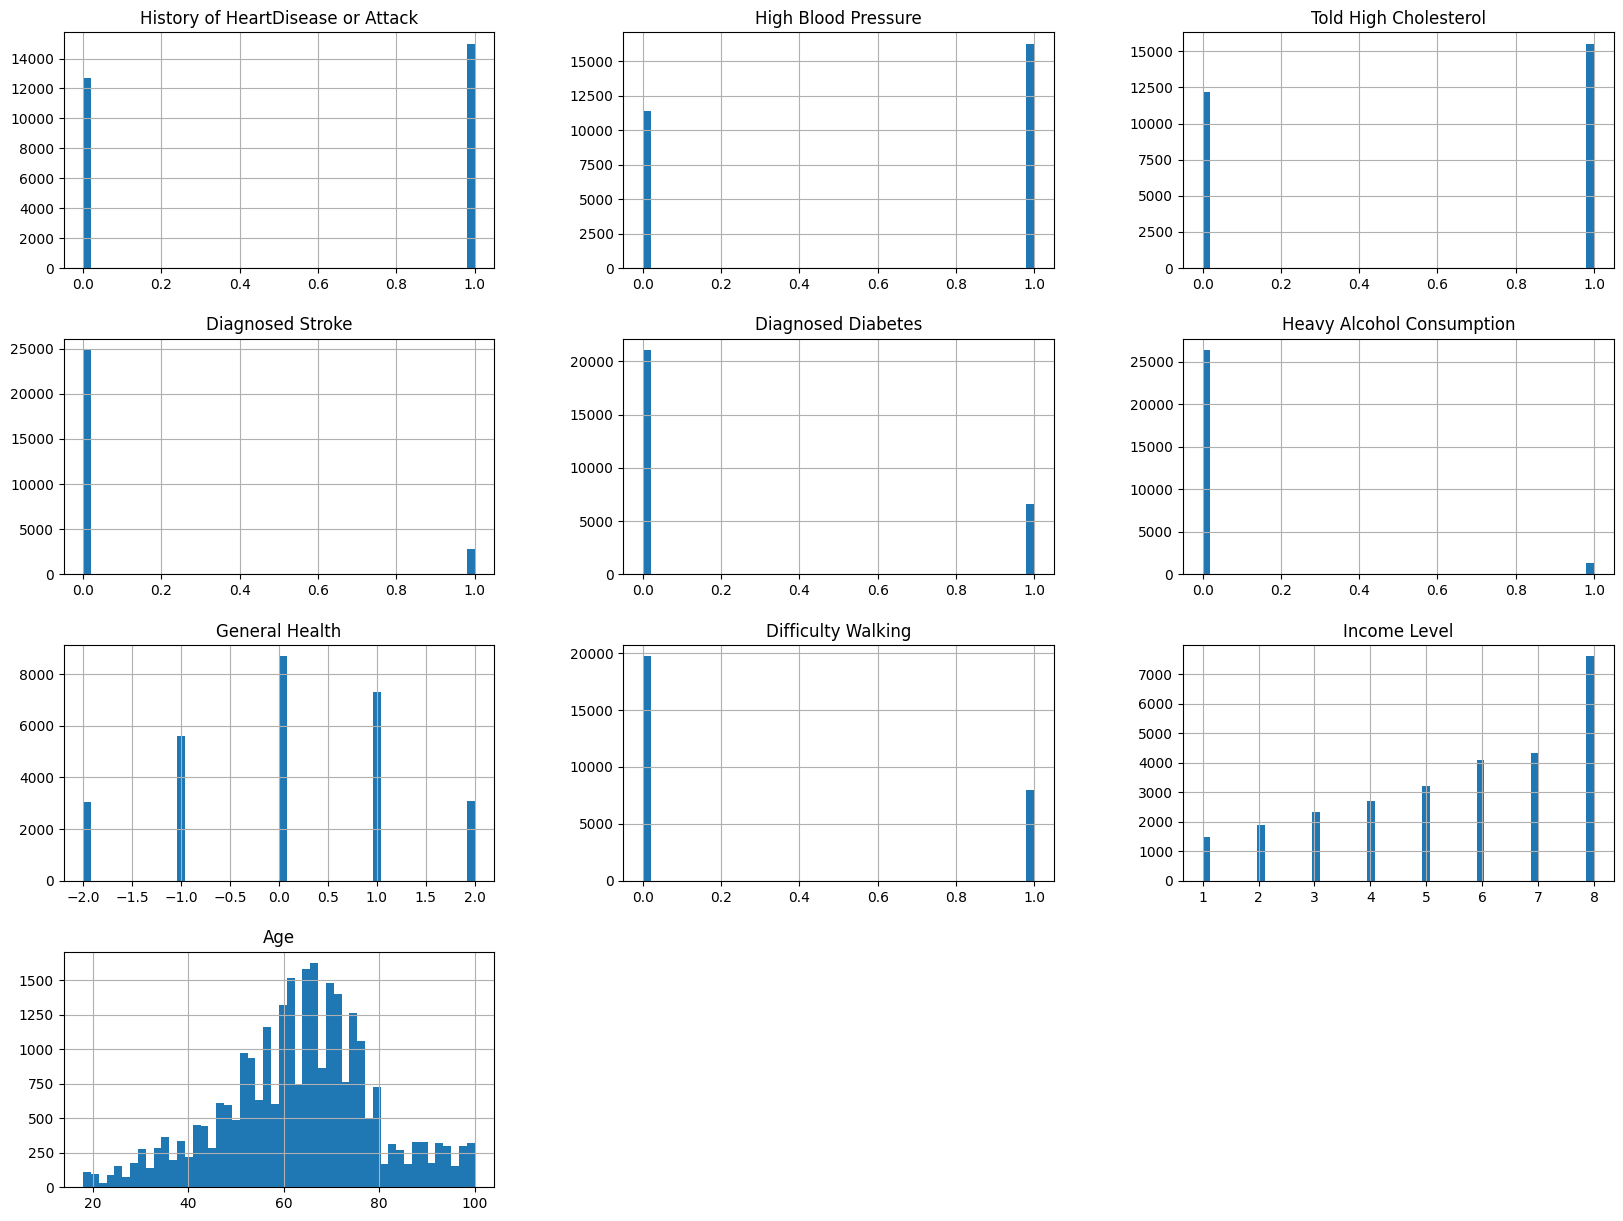

In [ ]:
train_df_tmp.hist(bins=50, figsize=(20,15))

## Mean

<Figure size 640x480 with 0 Axes>

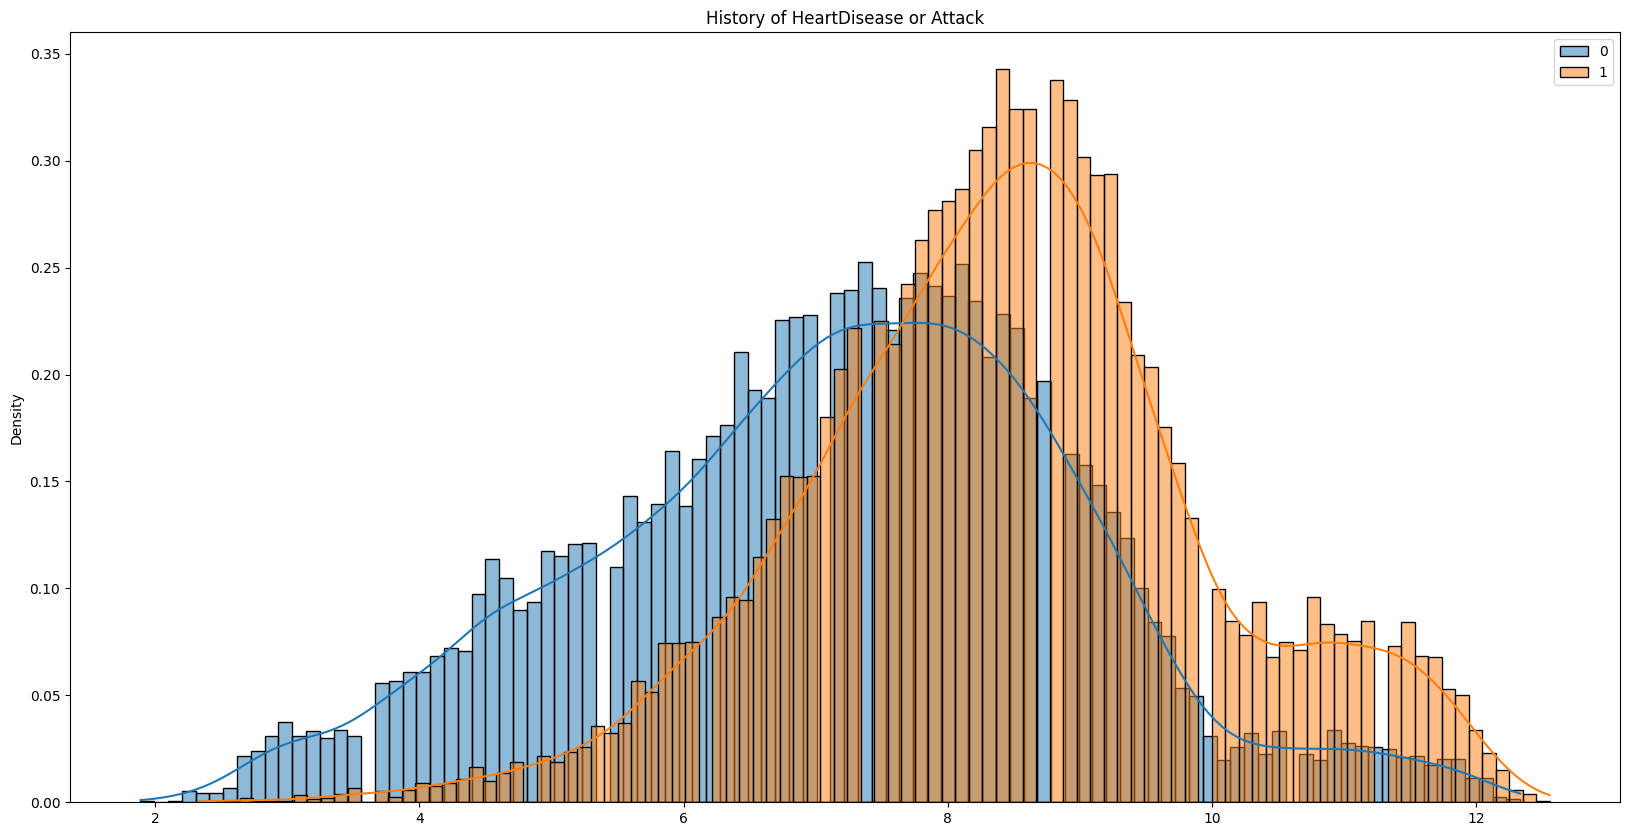

In [ ]:
plt.figure()
fig, ax = plt.subplots(1,1,figsize=(20,10))
features = train_df_tmp.columns.values[1:10]

uni = train_df_tmp['History of HeartDisease or Attack'].nunique()
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df_tmp[train_df_tmp['History of HeartDisease or Attack'] == i][features].mean(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Standard division

<Figure size 640x480 with 0 Axes>

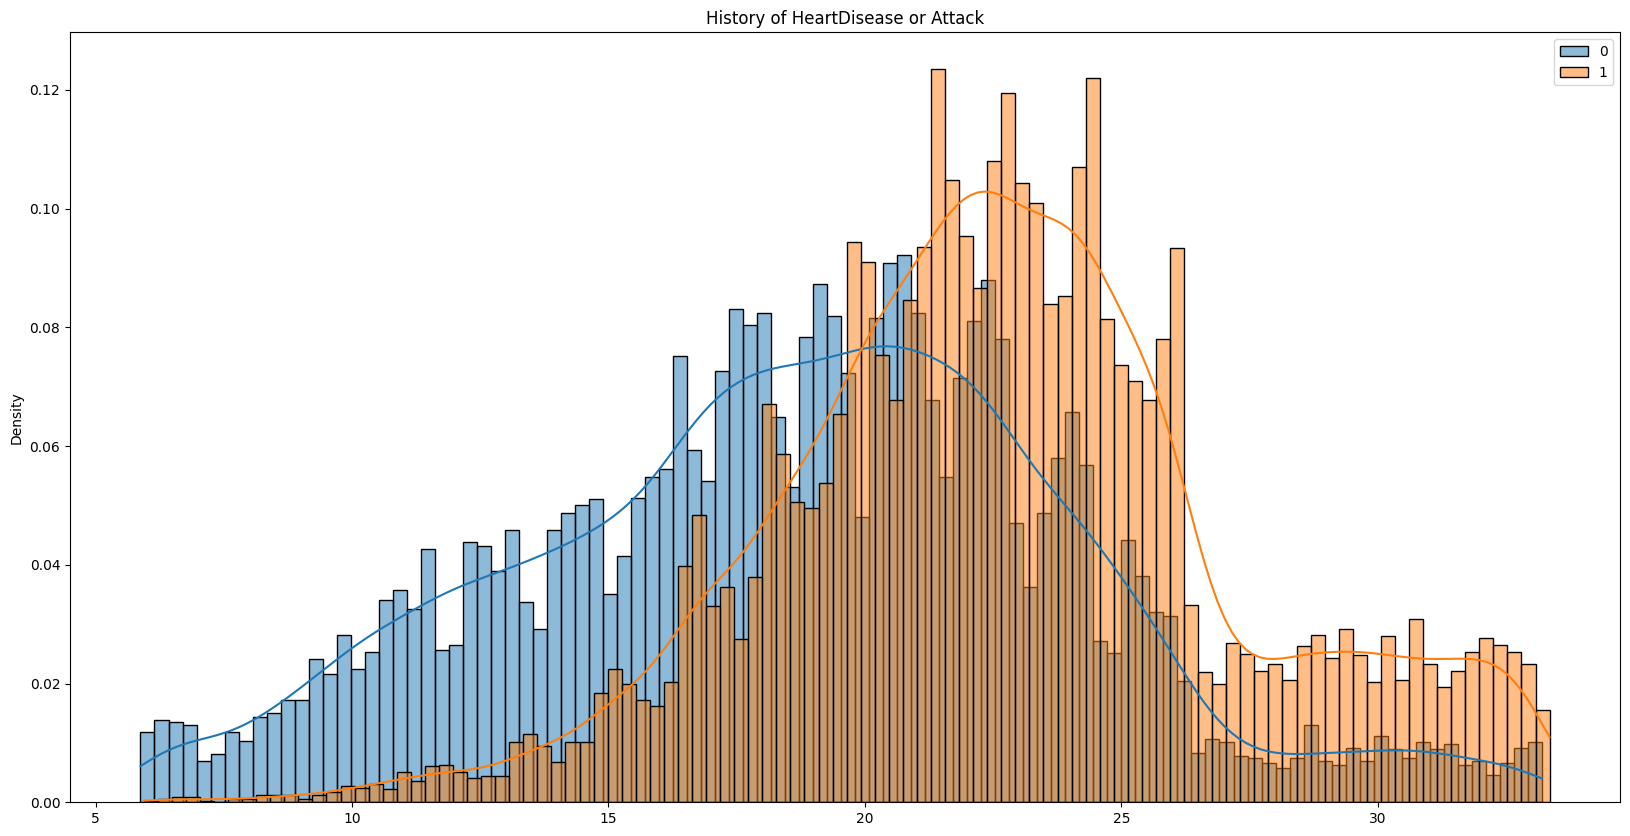

In [ ]:
plt.figure()
fig, ax = plt.subplots(1,1,figsize=(20,10))
features = train_df_tmp.columns.values[1:10]

uni = train_df_tmp['History of HeartDisease or Attack'].nunique()
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df_tmp[train_df_tmp['History of HeartDisease or Attack'] == i][features].std(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Min

<Figure size 640x480 with 0 Axes>

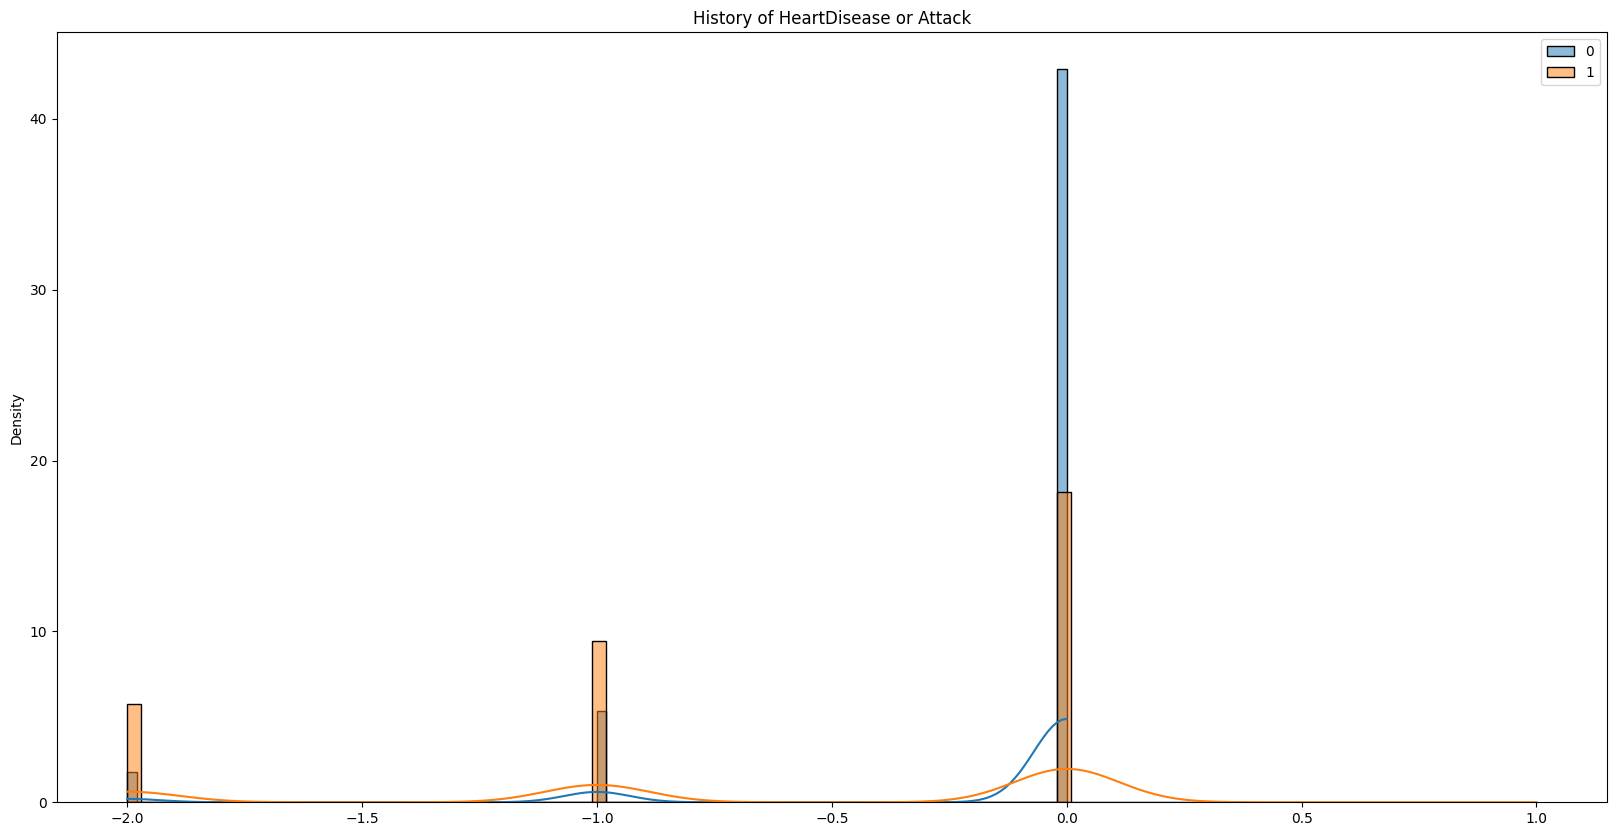

In [ ]:
plt.figure()
fig, ax = plt.subplots(1,1,figsize=(20,10))
features = train_df_tmp.columns.values[1:10]

uni = train_df_tmp['History of HeartDisease or Attack'].nunique()
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df_tmp[train_df_tmp['History of HeartDisease or Attack'] == i][features].min(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Max

<Figure size 640x480 with 0 Axes>

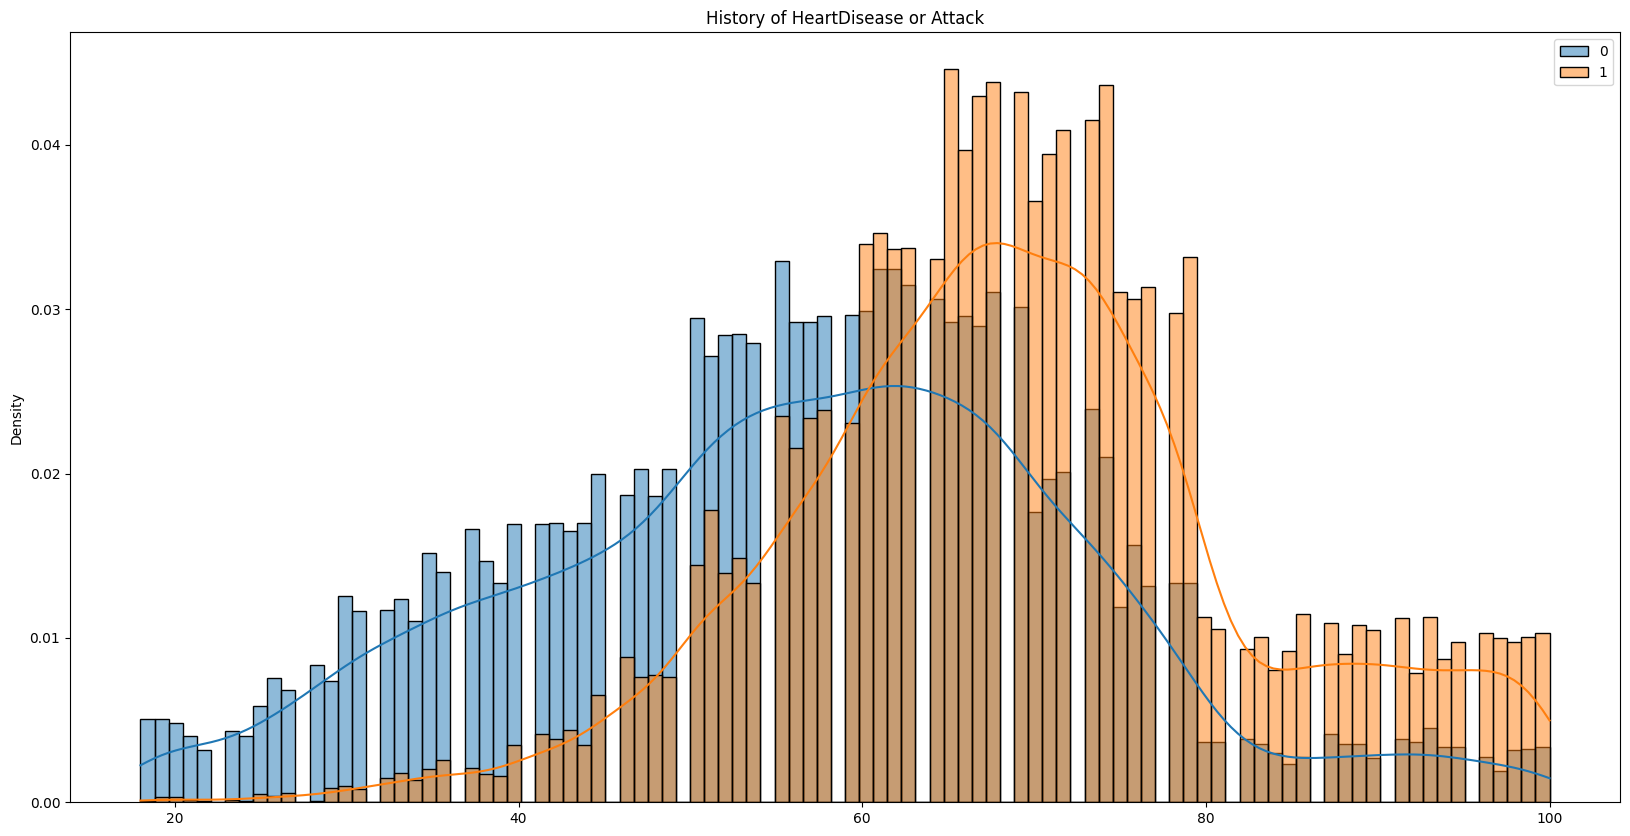

In [ ]:
plt.figure()
fig, ax = plt.subplots(1,1,figsize=(20,10))
features = train_df_tmp.columns.values[1:10]

uni = train_df_tmp['History of HeartDisease or Attack'].nunique()
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df_tmp[train_df_tmp['History of HeartDisease or Attack'] == i][features].max(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Medain

<Figure size 640x480 with 0 Axes>

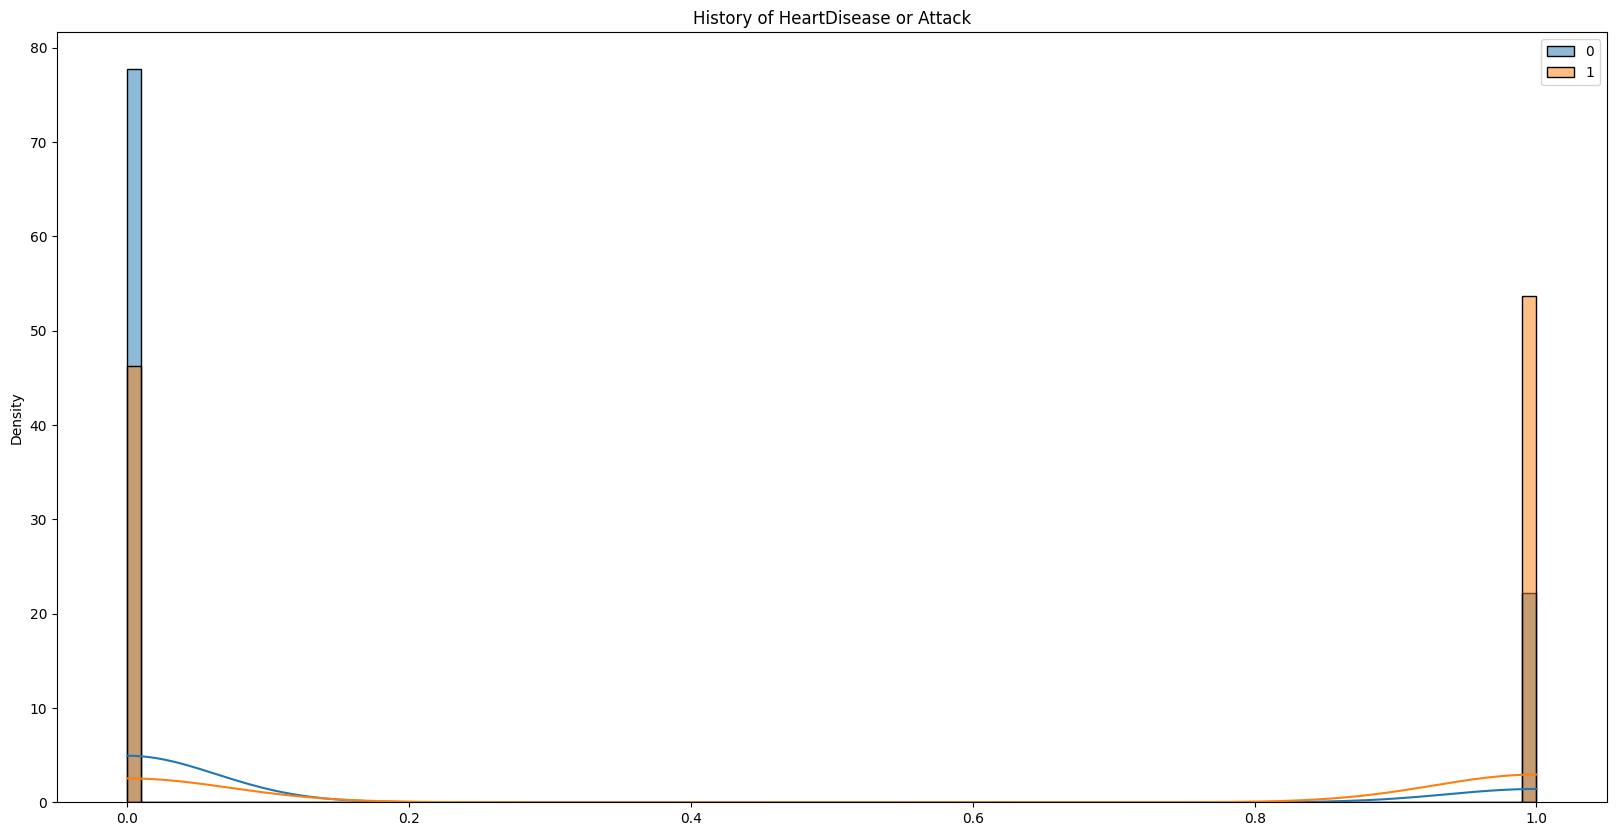

In [ ]:
plt.figure()
fig, ax = plt.subplots(1,1,figsize=(20,10))
features = train_df_tmp.columns.values[1:10]

uni = train_df_tmp['History of HeartDisease or Attack'].nunique()
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df_tmp[train_df_tmp['History of HeartDisease or Attack'] == i][features].median(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Summation

<Figure size 640x480 with 0 Axes>

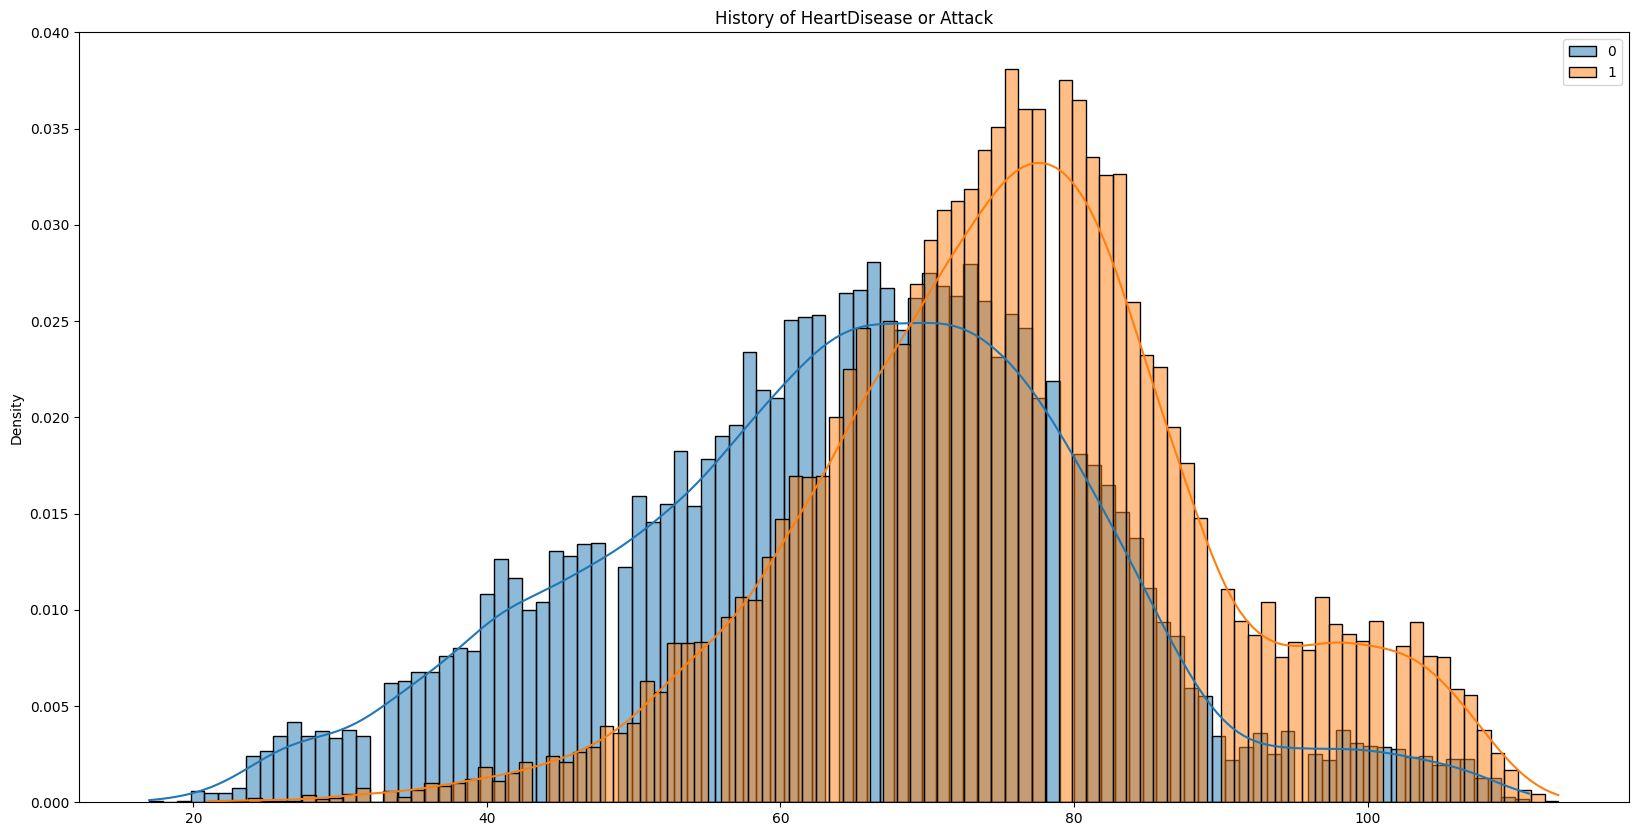

In [ ]:
plt.figure()
fig, ax = plt.subplots(1,1,figsize=(20,10))
features = train_df_tmp.columns.values[1:10]

uni = train_df_tmp['History of HeartDisease or Attack'].nunique()
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df_tmp[train_df_tmp['History of HeartDisease or Attack'] == i][features].sum(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Skew

<Figure size 640x480 with 0 Axes>

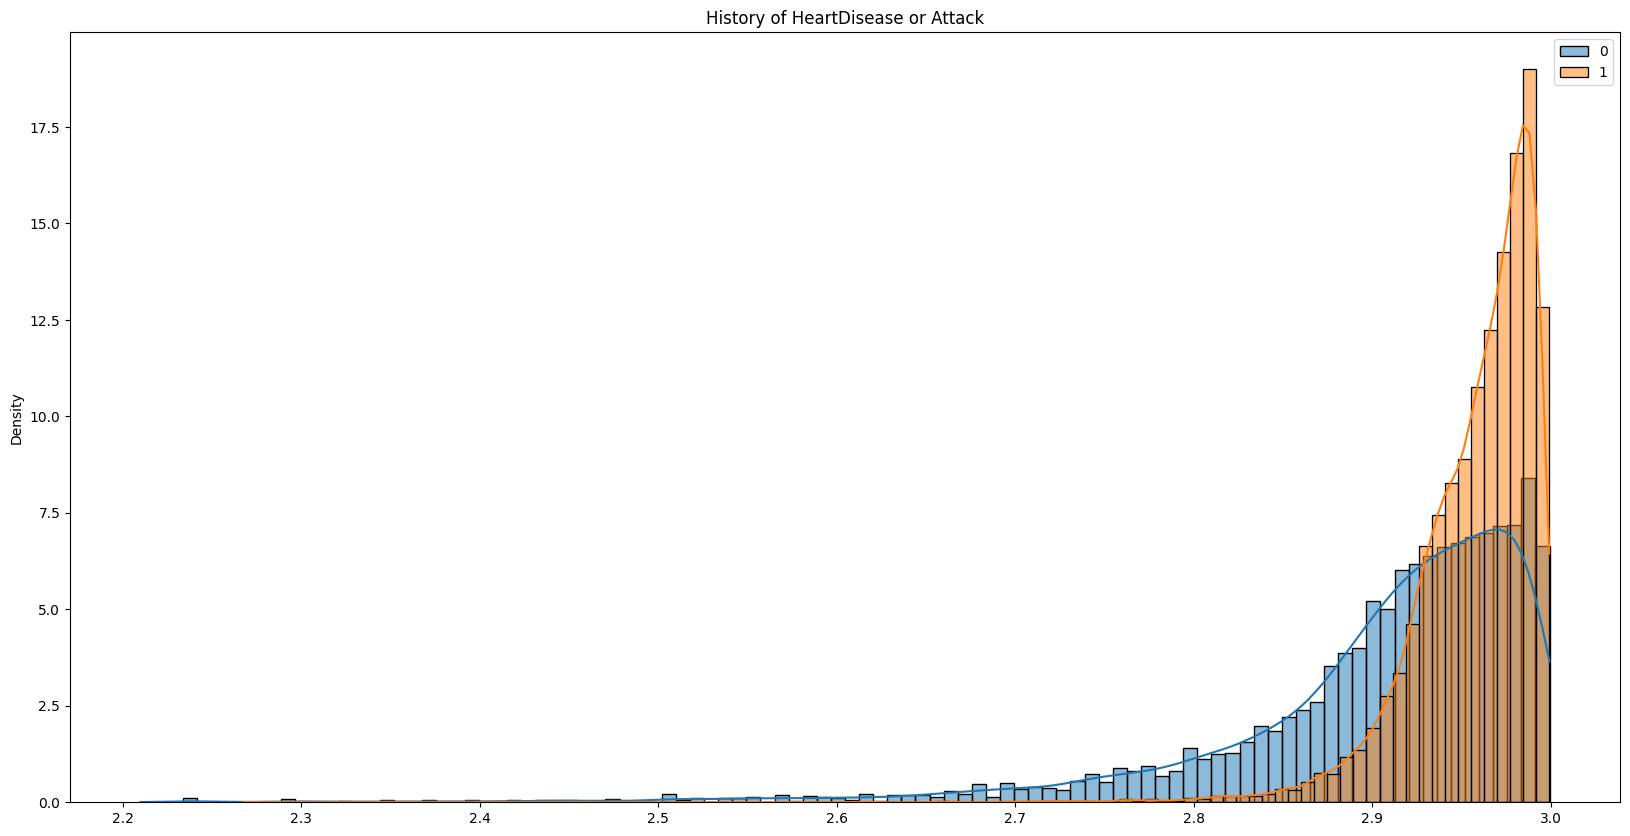

In [ ]:
plt.figure()
fig, ax = plt.subplots(1,1,figsize=(20,10))
features = train_df_tmp.columns.values[1:10]

uni = train_df_tmp['History of HeartDisease or Attack'].nunique()
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df_tmp[train_df_tmp['History of HeartDisease or Attack'] == i][features].skew(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Kurtosis

<Figure size 640x480 with 0 Axes>

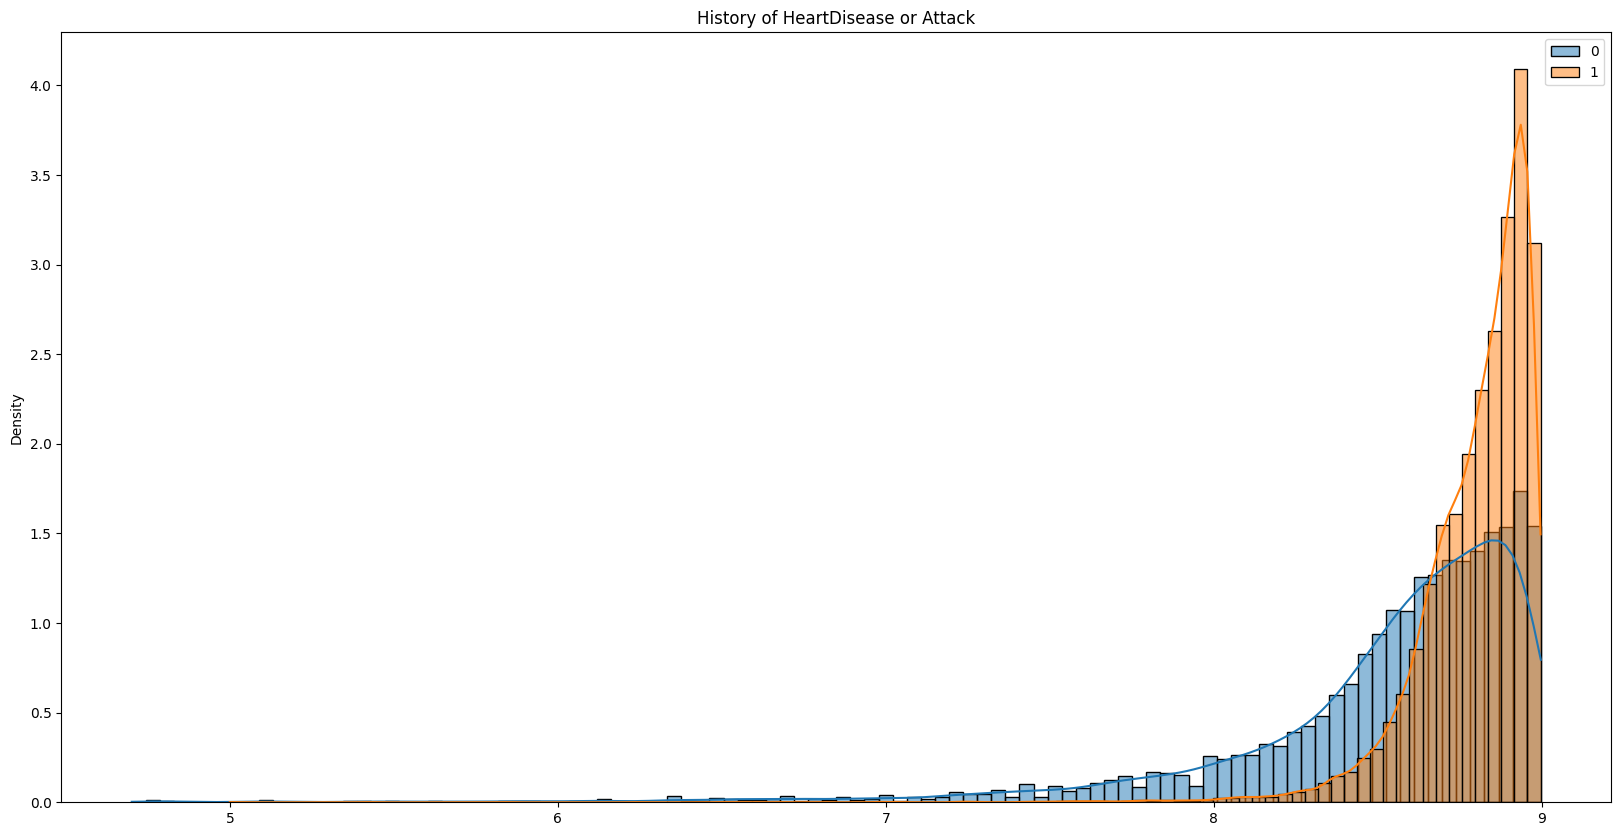

In [ ]:
plt.figure()
fig, ax = plt.subplots(1,1,figsize=(20,10))
features = train_df_tmp.columns.values[1:10]

uni = train_df_tmp['History of HeartDisease or Attack'].nunique()
plt.title("History of HeartDisease or Attack")
for i in range(uni):
    sns.histplot(data = train_df_tmp[train_df_tmp['History of HeartDisease or Attack'] == i][features].kurt(axis = 1),kde = True,bins = 100,label = str(i),stat = "density")
plt.legend()

plt.show()

## Correlation

<Axes: >

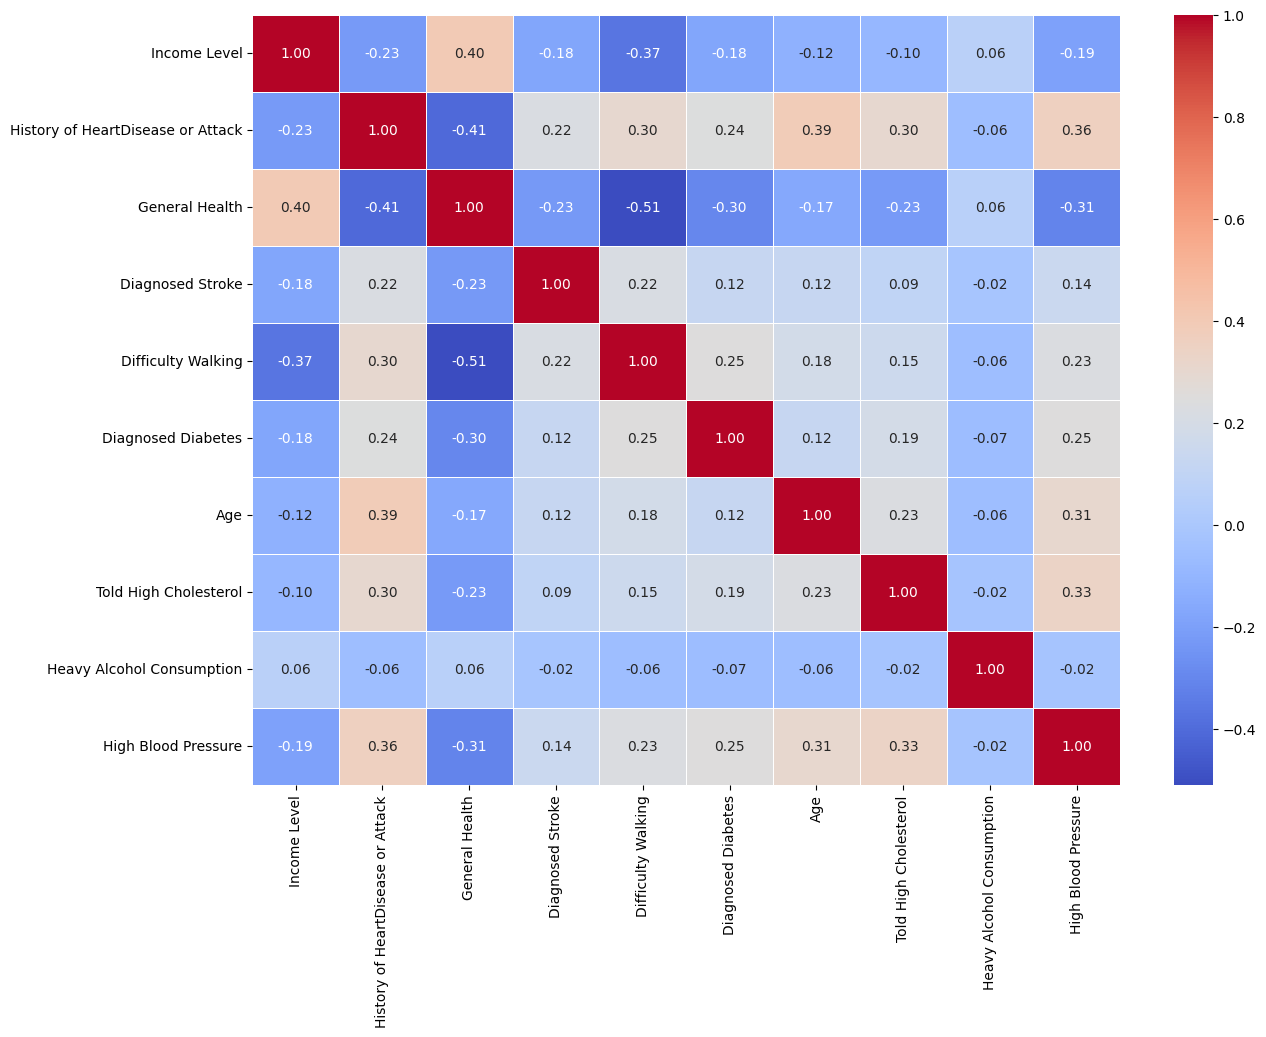

In [ ]:
numerical = list(set(train_df_tmp)-{'ID'})
corr_matrix = train_df_tmp[numerical].corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',linewidths=.5)

# **Feature Engineering**

In [ ]:
def feature_engineer(df):

    binary_map = {"Yes": 1, "No": 0}
    binary_cols = [
        "High Blood Pressure", "Told High Cholesterol", "Cholesterol Checked",
        "Smoked 100+ Cigarettes", "Diagnosed Stroke", "Diagnosed Diabetes",
        "Leisure Physical Activity", "Heavy Alcohol Consumption",
        "Health Care Coverage", "Doctor Visit Cost Barrier",
        "Difficulty Walking", "Vegetable or Fruit Intake (1+ per Day)"
    ]

    for col in binary_cols:
        if df[col].dtype == object:
            df[col + "_bin"] = df[col].map(binary_map)
        else:
            df[col + "_bin"] = df[col]


    def categorize_bmi(bmi): # GOOD
        if bmi < 18.5:
            return "Underweight"
        elif bmi < 25:
            return "Normal weight"
        elif bmi < 30:
            return "Overweight"
        else:
            return "Obese"

    df['BMI Category'] = df['Body Mass Index'].apply(categorize_bmi)

    df['Obesity Risk'] = ((df['Body Mass Index'] >= 30) & (df['Leisure Physical Activity'] == 'No')).astype(int)

    columns_to_drop = [
        "High Blood Pressure_bin", "Told High Cholesterol_bin", "Cholesterol Checked_bin",
        "Smoked 100+ Cigarettes_bin", "Diagnosed Stroke_bin", "Diagnosed Diabetes_bin",
        "Leisure Physical Activity_bin", "Heavy Alcohol Consumption_bin",
        "Health Care Coverage_bin", "Doctor Visit Cost Barrier_bin",
        "Difficulty Walking_bin", "Vegetable or Fruit Intake (1+ per Day)_bin",
        "Leisure Physical Activity",
    ]
    df = df.drop(columns=columns_to_drop)
    return df

In [ ]:
def statistic(df):
    new_df = pd.DataFrame()
    new_df['mean'] = df[features].mean(axis=1)
    new_df['max'] = df[features].max(axis=1)
    new_df['std'] = df[features].std(axis=1)
    new_df['sum'] = df[features].sum(axis=1)
    new_df['skew'] = df[features].skew(axis=1)
    new_df['kurt'] = df[features].kurt(axis=1)
    return new_df

In [ ]:
train_df_tmp = statistic(train_df_tmp)
test_df_tmp = statistic(test_df_tmp)

In [ ]:
train_df_tmp

,mean,max,std,sum,skew,kurt
0,6.333333,47.0,15.491933,57.0,2.834050,8.199523
1,7.111111,59.0,19.477195,64.0,2.988764,8.950383
2,7.444444,58.0,19.144915,67.0,2.895537,8.494701
3,8.222222,64.0,20.945034,74.0,2.984680,8.929838
4,7.222222,56.0,18.437582,65.0,2.914070,8.589762
...,...,...,...,...,...,...
31993,5.111111,36.0,11.868492,46.0,2.757964,7.772672
31994,6.888889,52.0,17.113185,62.0,2.878357,8.404692
31995,8.333333,65.0,21.412613,75.0,2.917713,8.605670
31997,7.111111,56.0,18.530006,64.0,2.886963,8.449637


In [ ]:
train_df = feature_engineer(train_df)
test_df = feature_engineer(test_df)

In [ ]:
train_df['mean'] = train_df_tmp['mean']
train_df['max'] = train_df_tmp['max']
train_df['std'] = train_df_tmp['std']
train_df['sum'] = train_df_tmp['sum']
train_df['skew'] = train_df_tmp['skew']
train_df['kurt'] = train_df_tmp['kurt']

In [ ]:
test_df['mean'] = test_df_tmp['mean']
test_df['max'] = test_df_tmp['max']
test_df['std'] = test_df_tmp['std']
test_df['sum'] = test_df_tmp['sum']
test_df['skew'] = test_df_tmp['skew']
test_df['kurt'] = test_df_tmp['kurt']

In [ ]:
train_df

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Heavy Alcohol Consumption,...,Age,Vegetable or Fruit Intake (1+ per Day),BMI Category,Obesity Risk,mean,max,std,sum,skew,kurt
0,train_183649,Yes,Yes,Yes,Yes,26.36,No,Yes,No,No,...,47,Yes,Overweight,0,6.333333,47.0,15.491933,57.0,2.834050,8.199523
1,train_001613,Yes,Yes,Yes,Yes,26.11,Yes,Yes,Yes,No,...,59,Yes,Overweight,0,7.111111,59.0,19.477195,64.0,2.988764,8.950383
2,train_072658,Yes,No,Yes,Yes,26.23,No,No,No,No,...,58,Yes,Overweight,0,7.444444,58.0,19.144915,67.0,2.895537,8.494701
3,train_217531,Yes,Yes,Yes,Yes,25.45,No,Yes,Yes,No,...,64,No,Overweight,0,8.222222,64.0,20.945034,74.0,2.984680,8.929838
4,train_220084,Yes,Yes,Yes,Yes,30.91,Yes,No,No,No,...,56,No,Obese,1,7.222222,56.0,18.437582,65.0,2.914070,8.589762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31995,train_195215,No,No,No,Yes,24.25,No,No,No,No,...,65,Yes,Normal weight,0,8.333333,65.0,21.412613,75.0,2.917713,8.605670
31996,train_186665,No,No,NaN,No,30.33,No,No,No,No,...,41,No,Obese,1,NaN,NaN,NaN,NaN,NaN,NaN
31997,train_081417,No,No,No,Yes,21.50,Yes,No,No,Yes,...,56,Yes,Normal weight,0,7.111111,56.0,18.530006,64.0,2.886963,8.449637
31998,train_097050,No,Yes,Yes,Yes,NaN,Yes,No,No,No,...,61,Yes,Obese,0,NaN,NaN,NaN,NaN,NaN,NaN


# **Modeling**

In [ ]:
save_path = 'best_model'
hyperparameters = {
    'GBM': [
        {'ag_args_fit': {'num_gpus': 0}},  # Train with CPU
        {'ag_args_fit': {'num_gpus': 1}}   # Train with GPU
    ],
    'CAT': [
        {'ag_args_fit': {'num_gpus': 0}},  # Train with CPU
        {'ag_args_fit': {'num_gpus': 1}}   # Train with GPU
    ],
    'XGB': [
        {'ag_args_fit': {'num_gpus': 0}},  # Train with CPU
        {'ag_args_fit': {'num_gpus': 1}}   # Train with GPU
    ],
    'RF': [
        {'ag_args_fit': {'num_gpus': 0}},  # Train with CPU
        {'ag_args_fit': {'num_gpus': 1}}   # Train with GPU
    ],

}
time_limit=600

In [ ]:
f2_metric = make_scorer(name='f2',
                        score_func=fbeta_score,
                        optimum=1,
                        greater_is_better=True,
                        beta=2)

In [ ]:
predictor = TabularPredictor(label='History of HeartDisease or Attack',
                            problem_type='binary',
                            path=save_path,
                            eval_metric=f2_metric
                            ).fit(
                                train_df,
                                presets='best_quality',
                                hyperparameters=hyperparameters,
                                time_limit=time_limit
                            )
print("Finish!")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          12
Pytorch Version:    2.10.0+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 39.49/39.49 GB
Total GPU Memory:   Free: 39.49 GB, Allocated: 0.00 GB, Total: 39.49 GB
GPU Count:          1
Memory Avail:       79.85 GB / 83.47 GB (95.7%)
Disk Space Avail:   191.86 GB / 235.68 GB (81.4%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a conse

Finish!


# **Evaluation**

In [ ]:
predictor.leaderboard(train_df,silent = True)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,RandomForest_BAG_L1,0.999900,0.786664,f2,0.622285,1.228298,2.641922,0.622285,1.228298,2.641922,1,True,3
1,RandomForest_2_BAG_L1,0.999900,0.786664,f2,0.626289,1.229031,2.636571,0.626289,1.229031,2.636571,1,True,4
2,XGBoost_BAG_L2,0.827851,0.819307,f2,3.461493,2.908711,60.912682,0.578111,0.109990,10.032981,2,True,12
3,XGBoost_2_BAG_L2,0.827741,0.819543,f2,3.446787,2.920029,58.764106,0.563405,0.121308,7.884405,2,True,13
4,LightGBM_BAG_L2,0.826109,0.820718,f2,2.960285,2.833962,60.110018,0.076903,0.035241,9.230318,2,True,8
5,LightGBM_2_BAG_L2,0.826099,0.820718,f2,2.958221,2.836026,64.446069,0.074839,0.037305,13.566369,2,True,9
6,WeightedEnsemble_L3,0.826089,0.820737,f2,3.540880,2.950050,71.289738,0.002483,0.006099,1.146739,3,True,14
7,XGBoost_2_BAG_L1,0.825914,0.814146,f2,0.539953,0.111717,8.075708,0.539953,0.111717,8.075708,1,True,6
8,RandomForest_BAG_L2,0.825401,0.807414,f2,3.365579,3.995239,54.915478,0.482197,1.196517,4.035777,2,True,10
9,RandomForest_2_BAG_L2,0.825401,0.807414,f2,3.370580,3.985731,54.893882,0.487198,1.187009,4.014181,2,True,11


In [ ]:
predictor.evaluate(train_df)

{'f2': 0.826088558166949,
 'accuracy': 0.796,
 'balanced_accuracy': np.float64(0.796),
 'mcc': np.float64(0.5944055274887059),
 'roc_auc': np.float64(0.896203125),
 'f1': 0.8047730127399965,
 'precision': 0.771590778759032,
 'recall': 0.8409375}

In [ ]:
predictions = predictor.predict(test_df)

# **Submission**

In [ ]:
sam_sub = pd.read_csv('/root/.cache/kagglehub/competitions/super-ai-engineer-ss-6-heart-disease-prediction/sample_submission.csv')
sam_sub

,ID,History of HeartDisease or Attack
0,test_000001,No
1,test_000002,No
2,test_000003,No
3,test_000004,NaN
4,test_000005,NaN
...,...,...
74356,test_074357,NaN
74357,test_074358,NaN
74358,test_074359,NaN
74359,test_074360,NaN


In [ ]:
sub = pd.DataFrame({
    'ID' : sam_sub['ID'],
    'History of HeartDisease or Attack' : predictions
})
sub.head()

,ID,History of HeartDisease or Attack
0,test_000001,Yes
1,test_000002,No
2,test_000003,Yes
3,test_000004,No
4,test_000005,No


In [ ]:
sub.to_csv('/content/submission_heart.csv', index=False)